**<font size="5">Applied Statistics</font>**

<font size="3">MSc in High Performance Computing Engineering, Computer Science and Engineering, Physics Engineering, ... cod 062102</font>

A.Y. 2025-2026

Prof. Michela Carlotta Massi - Dott. Vittorio Torri

---

<font size="4">**Lab V - Linear Regression**</font>

# Libraries

In [ ]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import numpy as np

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
import statsmodels.api as sm

In [ ]:
np.random.seed(1234)

In [ ]:
import scipy.stats as stats

# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/_Polimi/StatAppHPC/heart_failure_clinical_records_dataset_smhd.csv')

In [ ]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,bmi
0,75.00,0,582,0,20.73,1,265000.00,1.90,138.39,Male,0,4,True,30.82
1,55.00,0,7861,0,29.02,0,263358.03,1.10,131.90,Male,0,6,True,25.40
2,65.00,0,146,0,26.24,0,162000.00,1.30,143.66,Male,1,7,True,29.45
3,50.00,1,111,0,10.21,0,210000.00,1.90,135.03,Male,0,7,True,36.06
4,65.00,1,160,1,19.33,0,327000.00,2.70,136.08,Female,0,8,True,33.69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.00,0,61,1,38.05,1,155000.00,1.10,135.58,Male,1,270,False,25.60
295,55.00,0,1820,0,35.20,0,270000.00,1.20,142.02,Female,0,271,False,29.39
296,45.00,0,2060,1,62.32,0,742000.00,0.80,136.38,Female,0,278,False,20.71
297,45.00,0,2413,0,37.49,0,140000.00,1.40,133.91,Male,1,280,False,27.76


In [ ]:
cat_vars = ['anaemia', 'diabetes', 'high_blood_pressure',  'sex',  'smoking',  'DEATH_EVENT']
num_vars = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'bmi', 'time']

# Simple Linear Regression

Let's look at the scatterplot of bmi and ejection fraction

In [ ]:
TARGET = 'bmi'

/tmp/ipykernel_2616/865897703.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.relplot(x="ejection_fraction", y="bmi", palette="muted",


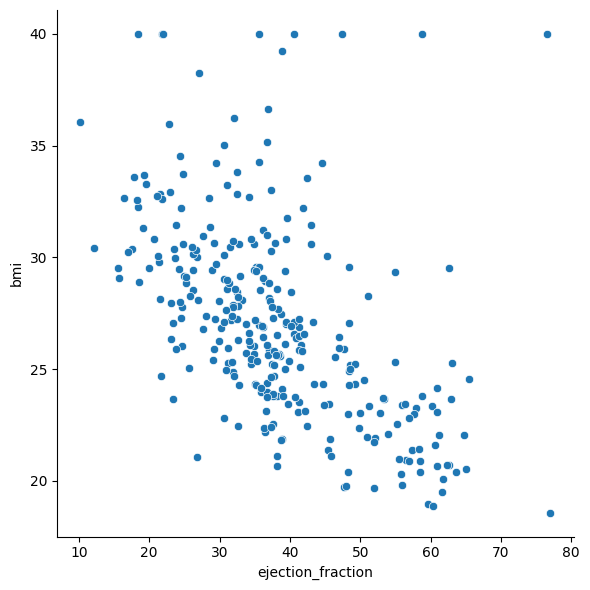

In [ ]:
sns.relplot(x="ejection_fraction", y="bmi", palette="muted",
            height=6, data=df)

It looks like there is a relationship between them: we can try to predict BMI based on ejection fraction

$$ bmi = \beta_0 + \beta_1 \cdot ef + \epsilon $$

In [ ]:
X = df['ejection_fraction'].values.reshape(-1,1)
y = df['bmi']

In [ ]:
X

array([[20.72719503],
       [29.0182135 ],
       [26.24384702],
       [10.20774141],
       [19.33171494],
       [35.60830264],
       [20.00570868],
       [64.74522091],
       [63.64964487],
       [35.62711417],
       [36.91730026],
       [24.64373731],
       [31.09298612],
       [36.49764547],
       [35.88275379],
       [49.97883583],
       [35.14953344],
       [15.73624933],
       [24.17359747],
       [54.93096893],
       [24.49318143],
       [30.65974616],
       [34.88618134],
       [59.67835102],
       [31.13162223],
       [45.31321666],
       [36.1256288 ],
       [52.74429614],
       [40.64502546],
       [33.80501417],
       [42.98902647],
       [44.57258949],
       [38.56547582],
       [24.56161919],
       [52.09949439],
       [36.69783352],
       [55.94185725],
       [51.20422458],
       [34.16220259],
       [37.27944959],
       [18.60095843],
       [33.19728341],
       [47.70838053],
       [49.84492965],
       [57.40156054],
       [35

In [ ]:
X_const = sm.add_constant(X)

In [ ]:
X_const

array([[ 1.        , 20.72719503],
       [ 1.        , 29.0182135 ],
       [ 1.        , 26.24384702],
       [ 1.        , 10.20774141],
       [ 1.        , 19.33171494],
       [ 1.        , 35.60830264],
       [ 1.        , 20.00570868],
       [ 1.        , 64.74522091],
       [ 1.        , 63.64964487],
       [ 1.        , 35.62711417],
       [ 1.        , 36.91730026],
       [ 1.        , 24.64373731],
       [ 1.        , 31.09298612],
       [ 1.        , 36.49764547],
       [ 1.        , 35.88275379],
       [ 1.        , 49.97883583],
       [ 1.        , 35.14953344],
       [ 1.        , 15.73624933],
       [ 1.        , 24.17359747],
       [ 1.        , 54.93096893],
       [ 1.        , 24.49318143],
       [ 1.        , 30.65974616],
       [ 1.        , 34.88618134],
       [ 1.        , 59.67835102],
       [ 1.        , 31.13162223],
       [ 1.        , 45.31321666],
       [ 1.        , 36.1256288 ],
       [ 1.        , 52.74429614],
       [ 1.        ,

In [ ]:
model = sm.OLS(y, X_const)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.283
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     117.2
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           3.06e-23
Time:                        13:34:19   Log-Likelihood:                -821.26
No. Observations:                 299   AIC:                             1647.
Df Residuals:                     297   BIC:                             1654.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.5154      0.717     48.117      0.0

$$ R^2 = 1 - \frac{RSS}{TSS} = 1 - \frac{\sum{(y_i - \hat{y_i})^2}}{\sum{(y_i - \bar{y})^2}}$$

$$ MSE = \frac{1}{n} \sum_{i=1}^n (\hat{y_i}-y_i)^2$$

$$RMSE = \sqrt{MSE} $$

$$ MAE = \frac{1}{n} \sum_{i=1}^n |\hat{y_i}-y_i|$$

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = results.predict(X_const)

r2 = r2_score(y,y_pred)
mse = mean_squared_error(y,y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y,y_pred)

print(f'R2: {r2:.4f}')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')

R2: 0.2829
MSE: 14.2321
RMSE: 3.7725
MAE: 2.6544


/tmp/ipykernel_2616/2887155262.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.relplot(x="ejection_fraction", y="bmi", palette="muted",


<Axes: xlabel='ejection_fraction', ylabel='bmi'>

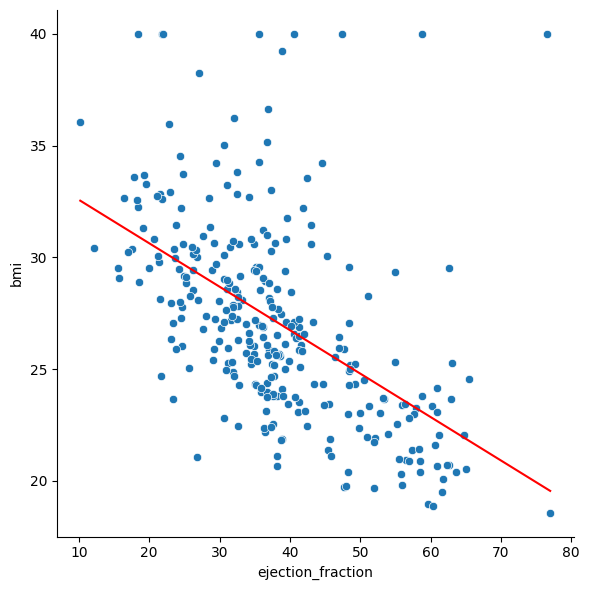

In [ ]:
X_plot = np.arange(np.min(X),np.max(X),0.1).reshape(-1,1)
X_plot = sm.add_constant(X_plot)
y_plot = results.predict(X_plot)
sns.relplot(x="ejection_fraction", y="bmi", palette="muted",
            height=6, data=df)
sns.lineplot(x=X_plot[:,1],y=y_plot,color='red')

## Confidence/Prediction intervals

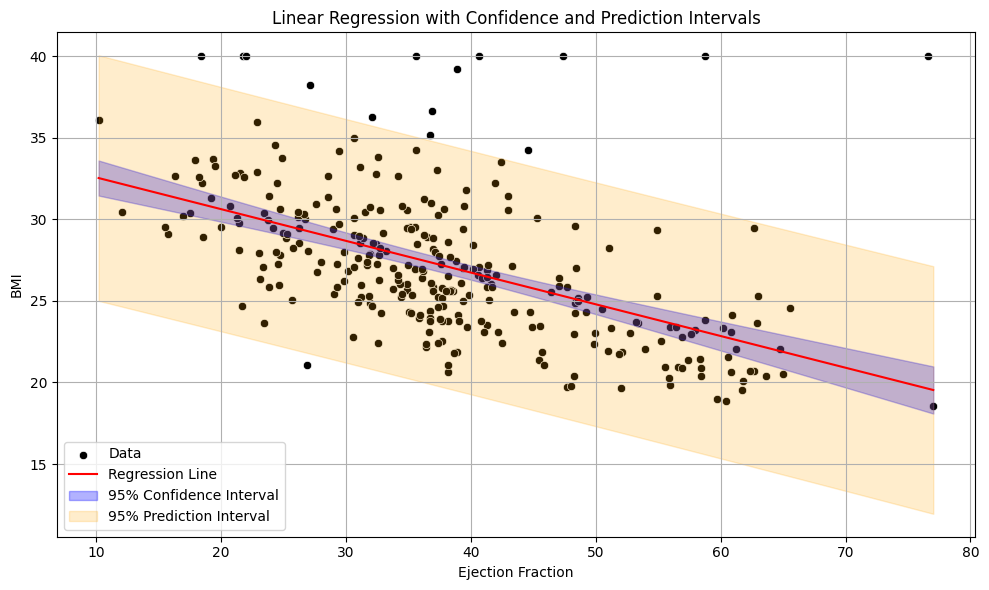

In [ ]:
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_const = sm.add_constant(X_plot)

# Predict with confidence intervals
predictions = results.get_prediction(X_plot_const)
summary_frame = predictions.summary_frame(alpha=0.05)  # 95% intervals

# Extract the values
y_pred = summary_frame['mean']
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['ejection_fraction'], y=df['bmi'], label='Data', color='black')
plt.plot(X_plot, y_pred, color='red', label='Regression Line')
plt.fill_between(X_plot.flatten(), ci_lower, ci_upper, color='blue', alpha=0.3, label='95% Confidence Interval')
plt.fill_between(X_plot.flatten(), pi_lower, pi_upper, color='orange', alpha=0.2, label='95% Prediction Interval')
plt.xlabel('Ejection Fraction')
plt.ylabel('BMI')
plt.title('Linear Regression with Confidence and Prediction Intervals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
x_mean = X.mean()
idx_closest = np.argmin(np.abs(X_plot.flatten() - x_mean))

ci_width_at_mean = ci_upper.iloc[idx_closest] - ci_lower.iloc[idx_closest]
pi_width_at_mean = pi_upper.iloc[idx_closest] - pi_lower.iloc[idx_closest]

print(f'CI width at mean(X) = {x_mean:.2f}: {ci_width_at_mean:.4f}')
print(f'PI width at mean(X) = {x_mean:.2f}: {pi_width_at_mean:.4f}')

print("CI width (start/end):", ci_upper.iloc[0] - ci_lower.iloc[0], ci_upper.iloc[-1] - ci_lower.iloc[-1])
print("PI width (start/end):", pi_upper.iloc[0] - pi_lower.iloc[0], pi_upper.iloc[-1] - pi_lower.iloc[-1])

CI width at mean(X) = 38.03: 0.8617
PI width at mean(X) = 38.03: 14.9234
CI width (start/end): 2.147469878187124 2.88785205970143
PI width (start/end): 15.05250862305327 15.17583864200242


Prediction and confidence intervals for a pecific point, ef=45

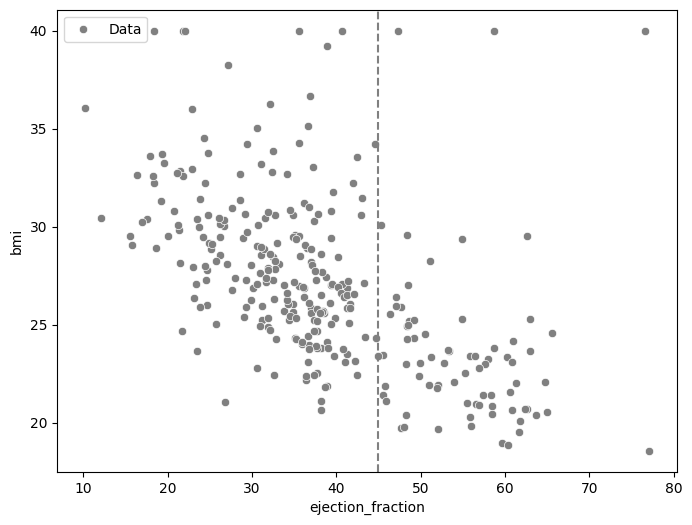

In [ ]:
### TODO
ef_point = 45
X_new = np.array([[1, ef_point]])  # Add constant manually

# Get predictions with confidence and prediction intervals

# Extract predicted values and intervals

# --- Plot ---
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['ejection_fraction'], y=df['bmi'], label='Data', color='gray')
plt.axvline(x=ef_point, color='grey', linestyle='--', label=f'EF = {ef_point}')


# Use errorbar to plot the PI for this observation and the CI for the mean at his x value


## Train-test set

So far we are evaluating the model on the same data it was trained on, but that's a limited (and bad) point of view

In [ ]:
from sklearn import model_selection

X = df[['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'ejection_fraction', 'time']]

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.20, random_state=1234)

train_index = X_train.index
test_index = X_test.index

In [ ]:
len(X_train)

239

In [ ]:
len(X_test)

60

In [ ]:
X_train

,age,anaemia,creatinine_phosphokinase,diabetes,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,ejection_fraction,time
52,60.00,0,3964,1,0,263358.03,6.80,131.94,Female,0,58.72,43
257,58.00,0,132,1,1,253000.00,1.00,137.35,Male,0,43.28,230
24,75.00,0,582,1,1,263358.03,1.83,142.58,Female,0,31.13,23
77,42.00,0,102,1,0,237000.00,1.20,133.33,Male,0,40.14,74
33,50.00,1,159,1,0,302000.00,1.20,141.31,Female,0,24.56,29
...,...,...,...,...,...,...,...,...,...,...,...,...
152,50.00,0,115,0,1,184000.00,0.90,134.81,Male,1,49.23,118
204,78.00,1,64,0,0,277000.00,0.70,141.25,Male,1,45.51,187
53,70.00,1,69,1,1,351000.00,1.00,135.82,Female,0,45.74,44
294,62.00,0,61,1,1,155000.00,1.10,135.58,Male,1,38.05,270


We can now fit the model on the training data

In [ ]:
X_train_1 = X_train[['ejection_fraction']]
X_test_1 = X_test[['ejection_fraction']]
X_train_1 = sm.add_constant(X_train_1)
X_test_1 = sm.add_constant(X_test_1)

model = sm.OLS(y_train, X_train_1)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.278
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     91.11
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           1.76e-18
Time:                        13:34:21   Log-Likelihood:                -664.47
No. Observations:                 239   AIC:                             1333.
Df Residuals:                     237   BIC:                             1340.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                34.7489      0.82

In [ ]:
### TODO: COMPUTE MSE AND R^2 ON TEST DATA
y_pred_train = results.predict(X_train_1)
r2 = r2_score(y_train,y_pred_train)
mse = mean_squared_error(y_train,y_pred_train)
mae = mean_absolute_error(y_train,y_pred_train)
print('TRAIN')
print(f'R2: {r2:.4f}')
print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')

print('TEST')
y_pred_test = results.predict(X_test_1)
r2 = r2_score(y_test,y_pred_test)
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
print(f'R2: {r2:.4f}')
print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')

TRAIN
R2: 0.2777
MSE: 15.2184
MAE: 2.7574
TEST
R2: 0.2995
MSE: 10.3824
MAE: 2.3385


# Multiple linear regression

## Multiple input variables

$$ bmi = \beta_0 + \beta_1 \cdot age + \beta_2 \cdot \text{ creatinine_phosphokinase } + ... + \epsilon $$

In [ ]:
variables = num_vars.copy()
variables.remove('bmi')

X_train_2 = X_train[variables]
X_test_2 = X_test[variables]
X_train_2 = sm.add_constant(X_train_2)
X_test_2 = sm.add_constant(X_test_2)

In [ ]:
model = sm.OLS(y_train, X_train_2)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     119.2
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           5.01e-73
Time:                        13:34:24   Log-Likelihood:                -520.64
No. Observations:                 239   AIC:                             1057.
Df Residuals:                     231   BIC:                             1085.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

The condition number is a measure of how sensitive the solution of linear equations (like the ones for regression coefficients $\beta$) are to small changes in the input data.

In regression a high condition number implies near-linear dependencies or strongly correlated directions in feature space, even if not visible in pairwise correlations.

$$ R^2 = 1 - \frac{RSS}{TSS} = 1 - \frac{\sum{(y_i - \hat{y_i})^2}}{\sum{(y_i - \bar{y})^2}}$$

$$ AdjR^2 = 1 - \frac{n - 1}{n - p -1} \frac{RSS}{TSS} = 1 - \frac{n - 1}{n - p -1} (1 - R^2)$$

where $p$ is the number of regressors

In [ ]:
y_pred = results.predict(X_test_2)
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
n = len(y_test)
p = X_test_2.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

R2: 0.6238
adj_R2: 0.5648
MSE: 5.5757


## Collinearity

The Variance Inflation Factor (VIF) indicates how good a variable can be predicted from the others

$$
VIF_j = \frac{1}{1 - R^2_j}
$$

where $R^2_j$ is the $R^2$ of the linear regression model predicting variable $j$ from all other variables

A high VIF means there is collinearity with some other variable

Rule of thumb: VIF > 5 for a variable is problematic

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

data = X_train_2

vif_data = pd.DataFrame()
vif_data["Variable"] = data.columns

vif_data["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]

print(vif_data)

                   Variable     VIF
0                     const 1158.00
1                       age    1.12
2  creatinine_phosphokinase    1.02
3         ejection_fraction    1.04
4                 platelets    1.02
5          serum_creatinine    1.07
6              serum_sodium    1.07
7                      time    1.07


The correlation coefficients can also identify collinearity, but not always. If a variable $X_1$ is a linear transformation of a variable $X_2$, their linear correlation coefficient will be high. But if the collinearity involves a group of variable, then it might not be evident from the correlation matrix

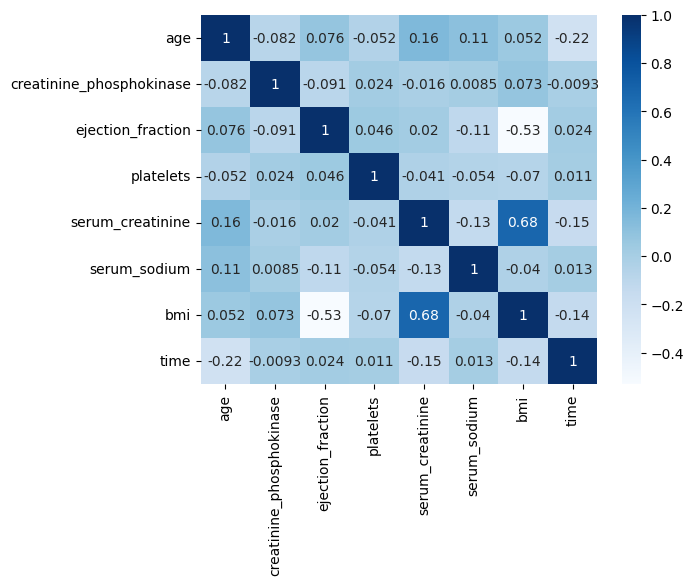

In [ ]:
sns.heatmap(df[num_vars].corr(), cmap="Blues",annot=True);

## Scale variables

Numerical variables having different scales are often problematic. Many models have their coefficients' computation affected by this, but while this is not the case of linear regression with least square method, it is still useful to **standardize** the features for interpretability of coefficients and to reduce the condition numer when it is not due to a direct multicollinearity among the variables. The VIF is scale invariant, but the condition number is not.

Moreover, this is necessary when penalizations are introduced in linear regression models (more on this in the next lectures)

To standardize a variable x:

$$ z = \frac{x - \mu }{\sigma}$$

$$ $$

In [ ]:
X_train_2 = X_train[variables]
X_test_2 = X_test[variables]

scaler = StandardScaler()
X_train_2_scaled = pd.DataFrame(scaler.fit_transform(X_train_2), columns=X_train_2.columns, index=X_train_2.index)
X_test_2_scaled = pd.DataFrame(scaler.transform(X_test_2), columns=X_test_2.columns, index=X_test_2.index)

X_train_2_scaled = sm.add_constant(X_train_2_scaled)
X_test_2_scaled = sm.add_constant(X_test_2_scaled)


In [ ]:
model = sm.OLS(y_train, X_train_2_scaled)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     119.2
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           5.01e-73
Time:                        13:34:24   Log-Likelihood:                -520.64
No. Observations:                 239   AIC:                             1057.
Df Residuals:                     231   BIC:                             1085.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [ ]:
y_pred = results.predict(X_test_2_scaled)
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
n = len(y_test)
p = X_test_2_scaled.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

R2: 0.6238
adj_R2: 0.5648
MSE: 5.5757


## Reduce the number of variables

### EF + creatinine

$$ bmi = \beta_0 + \beta_1 \cdot ef + \beta_2 \cdot creatinine + \epsilon $$

In [ ]:
variables = ['ejection_fraction', 'serum_creatinine']

X_train_3 = X_train[variables]
X_test_3 = X_test[variables]
X_train_3 = sm.add_constant(X_train_3)
X_test_3 = sm.add_constant(X_test_3)

In [ ]:
model = sm.OLS(y_train, X_train_3)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     418.2
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           2.64e-78
Time:                        13:34:24   Log-Likelihood:                -522.44
No. Observations:                 239   AIC:                             1051.
Df Residuals:                     236   BIC:                             1061.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                30.9120      0.48

In [ ]:
y_pred = results.predict(X_test_3)
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
n = len(y_test)
p = X_test_3.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

R2: 0.6279
adj_R2: 0.6080
MSE: 5.5148


with 2 regressors we can still visualize a plane:

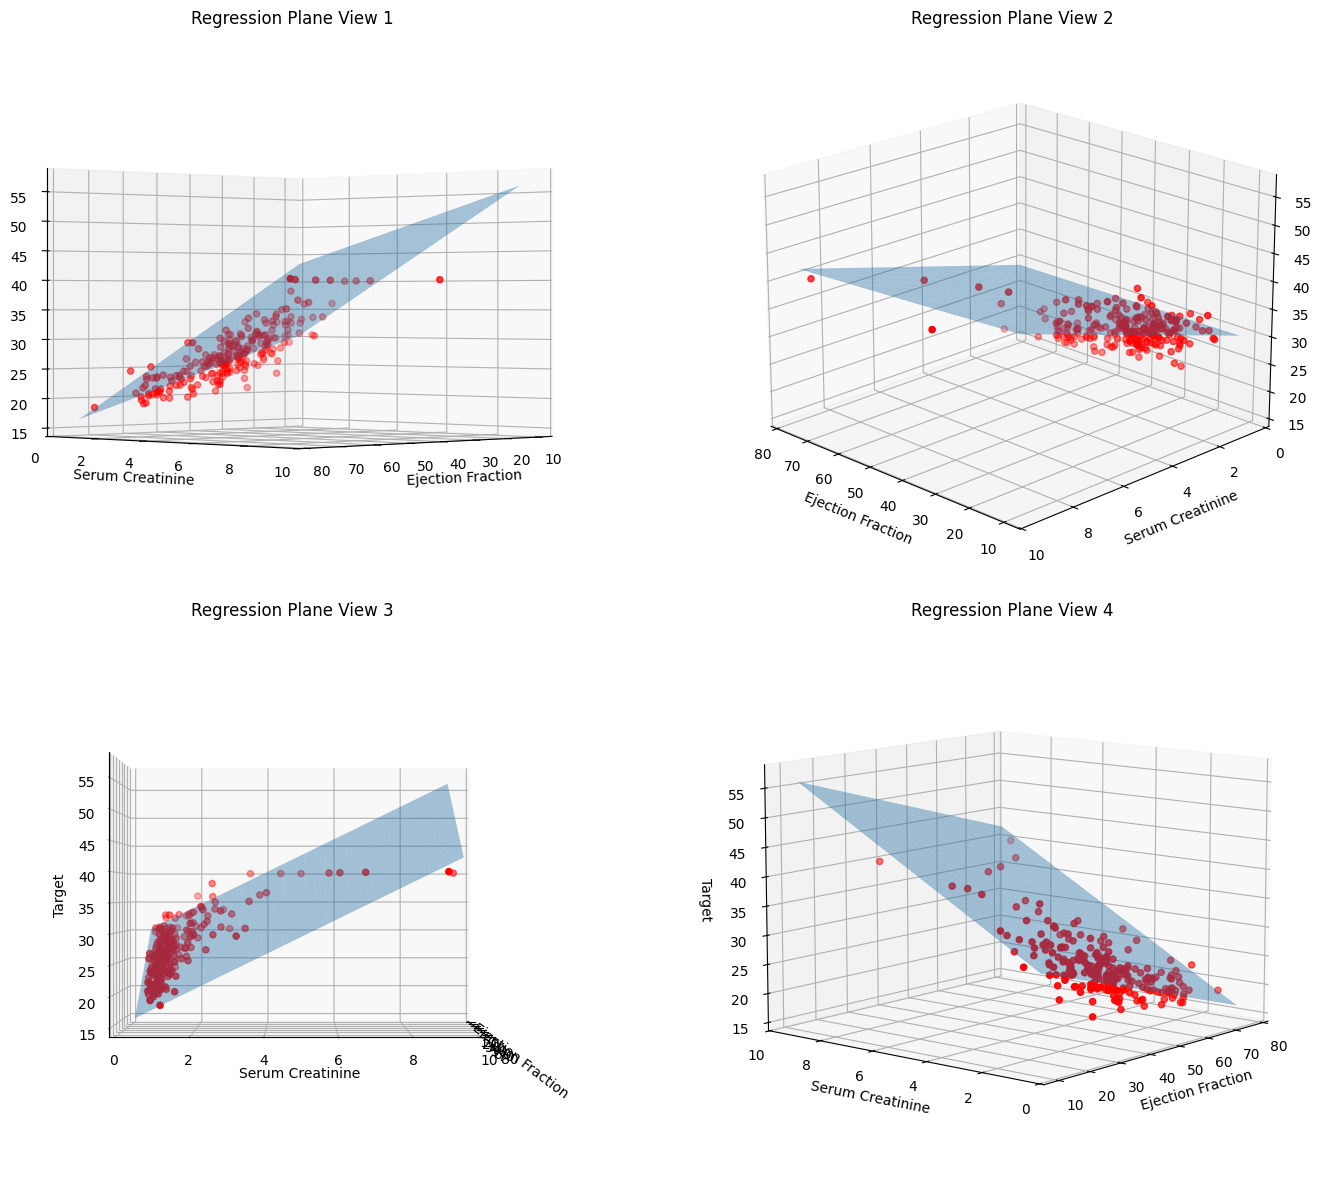

In [ ]:
x1 = X_train_3['ejection_fraction']
x2 = X_train_3['serum_creatinine']
y = y_train

# Get model coefficients
b0, b1, b2 = results.params

# Create a grid for plotting the regression plane
x1_grid, x2_grid = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30)
)

# Compute predicted y values over the grid
y_pred_grid = b0 + b1 * x1_grid + b2 * x2_grid

# Plot
fig = plt.figure(figsize=(16, 12))

views = [
    (0, 45),
    (20, 135),
    (0, 0),
    (10, 220)
]

titles = [
    "Regression Plane View 1",
    "Regression Plane View 2",
    "Regression Plane View 3",
    "Regression Plane View 4"
]

for i, (elev, azim) in enumerate(views):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    ax.scatter(x1, x2, y, color='r', label='Data')
    ax.plot_surface(x1_grid, x2_grid, y_pred_grid, alpha=0.4)
    ax.set_xlabel('Ejection Fraction')
    ax.set_ylabel('Serum Creatinine')
    ax.set_zlabel('Target')
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(titles[i])

plt.tight_layout()
plt.show()

with standardization:

In [ ]:
X_train_3 = X_train[variables]
X_test_3 = X_test[variables]

scaler = StandardScaler()
X_train_3_scaled = pd.DataFrame(scaler.fit_transform(X_train_3), columns=X_train_3.columns, index=X_train_3.index)
X_test_3_scaled = pd.DataFrame(scaler.transform(X_test_3), columns=X_test_3.columns, index=X_test_3.index)

X_train_3_scaled = sm.add_constant(X_train_3_scaled)
X_test_3_scaled = sm.add_constant(X_test_3_scaled)


In [ ]:
model = sm.OLS(y_train, X_train_3_scaled)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     418.2
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           2.64e-78
Time:                        13:34:26   Log-Likelihood:                -522.44
No. Observations:                 239   AIC:                             1051.
Df Residuals:                     236   BIC:                             1061.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                27.2106      0.14

In [ ]:
y_pred = results.predict(X_test_3_scaled)
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
n = len(y_test)
p = X_test_3_scaled.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

R2: 0.6279
adj_R2: 0.6080
MSE: 5.5148


### EF + creatinine + time

$$ bmi = \beta_0 + \beta_1 \cdot ef + \beta_2 \cdot creatinine + \beta_3 \cdot time + \epsilon $$

In [ ]:
# TODO at home

## Polynomial features

A linear regression model is linear in its parameters, but it can incorporate arbitrary nonlinear transformations of the input variables. For instance:

$$ bmi = \beta_0 + \beta_1 \cdot ef + \beta_2 \cdot ef^2 + \epsilon $$

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
variables = ['ejection_fraction']

X_train_6 = X_train[variables]
X_test_6 = X_test[variables]

polynomial2 = PolynomialFeatures(degree=2, include_bias=True)
X_train_6 = polynomial2.fit_transform(X_train_6)
X_test_6 = polynomial2.fit_transform(X_test_6)

In [ ]:
X_train_6

array([[1.00000000e+00, 5.87161647e+01, 3.44758799e+03],
       [1.00000000e+00, 4.32834411e+01, 1.87345628e+03],
       [1.00000000e+00, 3.11316222e+01, 9.69177903e+02],
       [1.00000000e+00, 4.01435845e+01, 1.61150738e+03],
       [1.00000000e+00, 2.45616192e+01, 6.03273137e+02],
       [1.00000000e+00, 4.70271847e+01, 2.21155610e+03],
       [1.00000000e+00, 1.84320101e+01, 3.39738996e+02],
       [1.00000000e+00, 5.79279121e+01, 3.35564299e+03],
       [1.00000000e+00, 4.20552508e+01, 1.76864412e+03],
       [1.00000000e+00, 2.34046843e+01, 5.47779247e+02],
       [1.00000000e+00, 4.10877268e+01, 1.68820129e+03],
       [1.00000000e+00, 3.56083026e+01, 1.26795122e+03],
       [1.00000000e+00, 6.01946554e+01, 3.62339653e+03],
       [1.00000000e+00, 3.81393371e+01, 1.45460903e+03],
       [1.00000000e+00, 1.69971506e+01, 2.88903128e+02],
       [1.00000000e+00, 2.94435247e+01, 8.66921147e+02],
       [1.00000000e+00, 5.87285187e+01, 3.44903890e+03],
       [1.00000000e+00, 3.12418

In [ ]:
scaler = StandardScaler()

# Scale everything except the constant term (column index 0)
X_train_6[:, 1:] = scaler.fit_transform(X_train_6[:, 1:])
X_test_6[:, 1:] = scaler.transform(X_test_6[:, 1:])

# Convert to DataFrame, maintaining the column names
cols = ['const', 'ef', 'ef^2']
#cols = polynomial2.get_feature_names_out()
X_train_6 = pd.DataFrame(X_train_6, columns=cols, index=train_index)
X_test_6 = pd.DataFrame(X_test_6, columns=cols, index=test_index)

In [ ]:
X_train_6

,const,ef,ef^2
52,1.00,1.68,1.78
257,1.00,0.42,0.26
24,1.00,-0.58,-0.62
77,1.00,0.16,0.00
33,1.00,-1.11,-0.97
...,...,...,...
152,1.00,0.90,0.79
204,1.00,0.60,0.45
53,1.00,0.62,0.47
294,1.00,-0.01,-0.16


In [ ]:
model = sm.OLS(y_train, X_train_6)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.300
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     50.68
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           4.87e-19
Time:                        13:34:26   Log-Likelihood:                -660.64
No. Observations:                 239   AIC:                             1327.
Df Residuals:                     236   BIC:                             1338.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.2106      0.250    108.884      0.0

In [ ]:
y_pred = results.predict(X_test_6)
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
n = len(y_test)
p = X_test_6.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

R2: 0.2610
adj_R2: 0.2214
MSE: 10.9534


Let's plot the line fitted by this polinomial regression, compare to the simple regression on ef

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/tmp/ipykernel_2616/1508833571.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.relplot(y="bmi", x="ejection_fraction", palette="muted",


<Axes: xlabel='ejection_fraction', ylabel='bmi'>

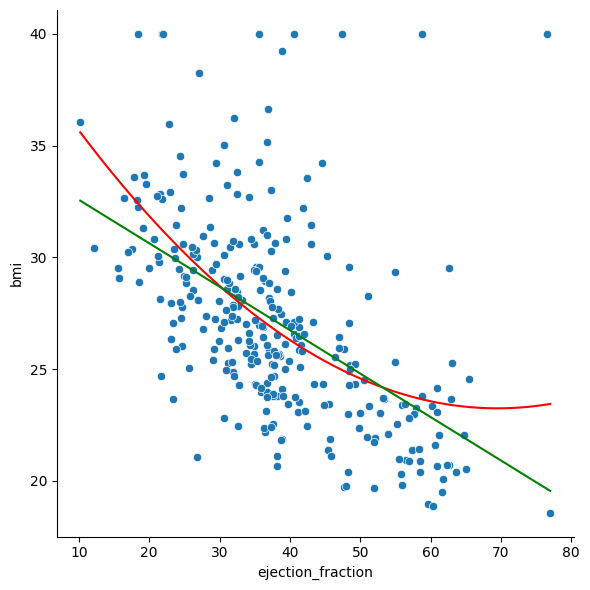

In [ ]:
X_plot = np.arange(np.min(X_train['ejection_fraction']),np.max(X_train['ejection_fraction']),0.1).reshape(-1,1)
X_plot_6 = polynomial2.transform(X_plot)

X_plot_6_scaled = X_plot_6
X_plot_6_scaled[:,1:] = scaler.transform(X_plot_6_scaled[:,1:])
y_plot_6 = results.predict(X_plot_6_scaled)

sns.relplot(y="bmi", x="ejection_fraction", palette="muted",
            height=6, data=df)
sns.lineplot(x=X_plot[:,0], y=y_plot_6,color='red')
sns.lineplot(x=X_plot[:,0], y=y_plot,color='green')

$$ bmi = \beta_0 + \beta_1 \cdot ef + \beta_2 \cdot creatinine + \beta_3 \cdot ef^2 + \beta_4 \cdot ef \cdot creatinine + \beta_5 \cdot creatinine^2 + \epsilon $$

In [ ]:
variables = ['ejection_fraction', 'serum_creatinine']

X_train_7 = X_train[variables]
X_test_7 = X_test[variables]

polynomial2 = PolynomialFeatures(degree=2, include_bias=True)
X_train_7 = polynomial2.fit_transform(X_train_7)
X_test_7 = polynomial2.fit_transform(X_test_7)

scaler = StandardScaler()

# Scale everything except the constant term (column index 0)
X_train_7[:, 1:] = scaler.fit_transform(X_train_7[:, 1:])
X_test_7[:, 1:] = scaler.transform(X_test_7[:, 1:])

# Convert to DataFrame, maintaining the column names
cols = polynomial2.get_feature_names_out()
X_train_7 = pd.DataFrame(X_train_7, columns=cols, index=train_index)
X_test_7 = pd.DataFrame(X_test_7, columns=cols, index=test_index)

In [ ]:
X_train_7

,1,ejection_fraction,serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2
52,1.00,1.68,4.77,1.78,5.75,4.74
257,1.00,0.42,-0.39,0.26,-0.20,-0.26
24,1.00,-0.58,0.35,-0.62,0.03,0.00
77,1.00,0.16,-0.21,0.00,-0.12,-0.21
33,1.00,-1.11,-0.21,-0.97,-0.43,-0.21
...,...,...,...,...,...,...
152,1.00,0.90,-0.48,0.79,-0.19,-0.28
204,1.00,0.60,-0.66,0.45,-0.39,-0.31
53,1.00,0.62,-0.39,0.47,-0.16,-0.26
294,1.00,-0.01,-0.30,-0.16,-0.23,-0.23


In [ ]:
model = sm.OLS(y_train, X_train_7)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     216.6
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           1.80e-85
Time:                        13:34:26   Log-Likelihood:                -496.43
No. Observations:                 239   AIC:                             1005.
Df Residuals:                     233   BIC:                             1026.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
1   

In [ ]:
y_pred = results.predict(X_test_7)
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
n = len(y_test)
p = X_test_7.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

R2: 0.6693
adj_R2: 0.6319
MSE: 4.9017


$$ bmi = \beta_0 + \beta_1 \cdot ef + \beta_2 \cdot creatinine + \beta_3 \cdot ef \cdot creatinine + \beta_4 \cdot creatinine^2 + \epsilon $$

In [ ]:
X_train_8 = X_train_7.drop('ejection_fraction^2', axis=1)
X_test_8 = X_test_7.drop('ejection_fraction^2', axis=1)

In [ ]:
X_train_8

,1,ejection_fraction,serum_creatinine,ejection_fraction serum_creatinine,serum_creatinine^2
52,1.00,1.68,4.77,5.75,4.74
257,1.00,0.42,-0.39,-0.20,-0.26
24,1.00,-0.58,0.35,0.03,0.00
77,1.00,0.16,-0.21,-0.12,-0.21
33,1.00,-1.11,-0.21,-0.43,-0.21
...,...,...,...,...,...
152,1.00,0.90,-0.48,-0.19,-0.28
204,1.00,0.60,-0.66,-0.39,-0.31
53,1.00,0.62,-0.39,-0.16,-0.26
294,1.00,-0.01,-0.30,-0.23,-0.23


In [ ]:
model = sm.OLS(y_train, X_train_8)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     271.7
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           1.11e-86
Time:                        13:34:26   Log-Likelihood:                -496.51
No. Observations:                 239   AIC:                             1003.
Df Residuals:                     234   BIC:                             1020.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
1   

In [ ]:
y_pred = results.predict(X_test_8)
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
n = len(y_test)
p = X_test_8.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

R2: 0.6688
adj_R2: 0.6382
MSE: 4.9087


## Categorical Features

To use them we need to transform categorical variables with one-hot encoding


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_feature = encoder.fit_transform(df[cat_vars])

df_encoded = pd.DataFrame(encoded_feature, columns=encoder.get_feature_names_out(cat_vars))

df_encoded = pd.concat([df.drop(cat_vars, axis=1), df_encoded], axis=1)
df_encoded

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,bmi,anaemia_1,diabetes_1,high_blood_pressure_1,sex_Male,smoking_1,DEATH_EVENT_True
0,75.00,582,20.73,265000.00,1.90,138.39,4,30.82,0.00,0.00,1.00,1.00,0.00,1.00
1,55.00,7861,29.02,263358.03,1.10,131.90,6,25.40,0.00,0.00,0.00,1.00,0.00,1.00
2,65.00,146,26.24,162000.00,1.30,143.66,7,29.45,0.00,0.00,0.00,1.00,1.00,1.00
3,50.00,111,10.21,210000.00,1.90,135.03,7,36.06,1.00,0.00,0.00,1.00,0.00,1.00
4,65.00,160,19.33,327000.00,2.70,136.08,8,33.69,1.00,1.00,0.00,0.00,0.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.00,61,38.05,155000.00,1.10,135.58,270,25.60,0.00,1.00,1.00,1.00,1.00,0.00
295,55.00,1820,35.20,270000.00,1.20,142.02,271,29.39,0.00,0.00,0.00,0.00,0.00,0.00
296,45.00,2060,62.32,742000.00,0.80,136.38,278,20.71,0.00,1.00,0.00,0.00,0.00,0.00
297,45.00,2413,37.49,140000.00,1.40,133.91,280,27.76,0.00,0.00,0.00,1.00,1.00,0.00


$$ bmi = \beta_0 + \beta_1 \cdot ef + \beta_2 \cdot DEATH\_EVENT\_True + \epsilon $$

In [ ]:
num_variables = ['ejection_fraction']
cat_variables = ['DEATH_EVENT_True']

X_train_9_num = X_train[num_variables]
X_test_9_num = X_test[num_variables]

X_train_9_cat = df_encoded.loc[train_index, cat_variables]
X_test_9_cat = df_encoded.loc[test_index, cat_variables]


# Concatenate the polynomial features with the one-hot encoded categorical variable
X_train_9 = np.concatenate([X_train_9_num, X_train_9_cat], axis=1)
X_test_9 = np.concatenate([X_test_9_num, X_test_9_cat], axis=1)

cols = num_variables + cat_variables
X_train_9 = pd.DataFrame(X_train_9, index=train_index, columns=cols)
X_test_9 = pd.DataFrame(X_test_9, index=test_index, columns=cols)

X_train_9 = sm.add_constant(X_train_9)
X_test_9 = sm.add_constant(X_test_9)

In [ ]:
model = sm.OLS(y_train, X_train_9)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     63.14
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           1.09e-22
Time:                        13:34:26   Log-Likelihood:                -652.12
No. Observations:                 239   AIC:                             1310.
Df Residuals:                     236   BIC:                             1321.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                32.9851      0.86

<Axes: xlabel='ejection_fraction', ylabel='bmi'>

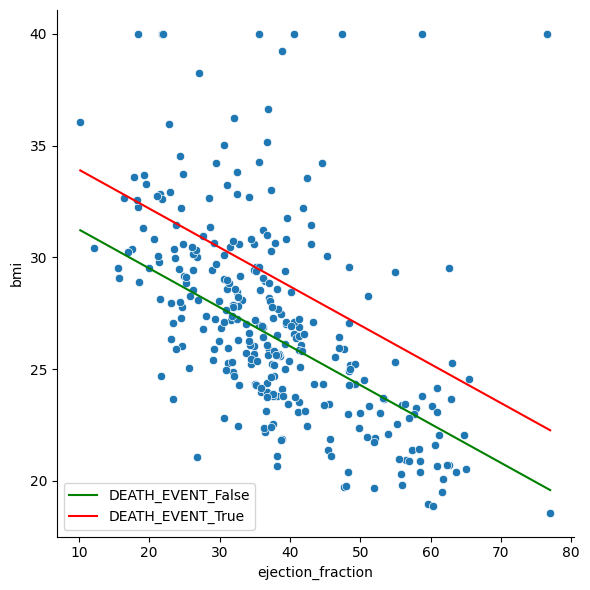

In [ ]:
X_plot = np.arange(np.min(df['ejection_fraction']), np.max(df['ejection_fraction']), 0.1).reshape(-1, 1)
X_plot = sm.add_constant(X_plot)

# Create two versions of X_plot, one with the binary variable = 0, one with binary variable = 1
X_plot_0 = np.hstack([X_plot, np.zeros((X_plot.shape[0], 1))])  # Add column of 0's for binary_var = 0
X_plot_1 = np.hstack([X_plot, np.ones((X_plot.shape[0], 1))])   # Add column of 1's for binary_var = 1

y_plot_0 = results.predict(X_plot_0)  # Prediction for binary_var = 0
y_plot_1 = results.predict(X_plot_1)  # Prediction for binary_var = 1

sns.relplot(x="ejection_fraction", y="bmi", height=6, data=df, legend=False)

sns.lineplot(x=X_plot[:, 1], y=y_plot_0, color='green', label='DEATH_EVENT_False')
sns.lineplot(x=X_plot[:, 1], y=y_plot_1, color='red', label='DEATH_EVENT_True')

In [ ]:
y_pred = results.predict(X_test_9)
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
n = len(y_test)
p = X_test_9.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

R2: 0.3593
adj_R2: 0.3250
MSE: 9.4958


$$ bmi = \beta_0 + \beta_1 \cdot ef + \beta_2 \cdot creatinine + \beta_3 \cdot ef \cdot creatinine + \beta_4 \cdot creatinine^2 + \beta_5 \cdot DEATH\_EVENT\_True + \epsilon $$

In [ ]:
num_variables = ['ejection_fraction', 'serum_creatinine']
cat_variables = ['DEATH_EVENT_True']

X_train_9_num = X_train[num_variables]
X_test_9_num = X_test[num_variables]

X_train_9_cat = df_encoded.loc[train_index, cat_variables]
X_test_9_cat = df_encoded.loc[test_index, cat_variables]

# Perform Polynomial Features transformation on the numerical data
polynomial2 = PolynomialFeatures(degree=2, include_bias=True)
X_train_9_poly = polynomial2.fit_transform(X_train_9_num)
X_test_9_poly = polynomial2.fit_transform(X_test_9_num)

# Scale the polynomial features except for the bias (constant) term
scaler = StandardScaler()
X_train_9_poly[:, 1:] = scaler.fit_transform(X_train_9_poly[:, 1:])
X_test_9_poly[:, 1:] = scaler.transform(X_test_9_poly[:, 1:])

# Concatenate the polynomial features with the one-hot encoded categorical variable
X_train_9 = np.concatenate([X_train_9_poly, X_train_9_cat], axis=1)
X_test_9 = np.concatenate([X_test_9_poly, X_test_9_cat], axis=1)

# Convert to DataFrame for easier handling
cols_poly = polynomial2.get_feature_names_out(num_variables)
cols = np.concatenate([cols_poly, X_train_9_cat.columns])

X_train_9 = pd.DataFrame(X_train_9, columns=cols, index=train_index)
X_test_9 = pd.DataFrame(X_test_9, columns=cols, index=test_index)

X_train_9.drop('ejection_fraction^2', axis=1, inplace=True)
X_test_9.drop('ejection_fraction^2', axis=1, inplace=True)


In [ ]:
X_train_9

,1,ejection_fraction,serum_creatinine,ejection_fraction serum_creatinine,serum_creatinine^2,DEATH_EVENT_True
52,1.00,1.68,4.77,5.75,4.74,1.00
257,1.00,0.42,-0.39,-0.20,-0.26,0.00
24,1.00,-0.58,0.35,0.03,0.00,1.00
77,1.00,0.16,-0.21,-0.12,-0.21,0.00
33,1.00,-1.11,-0.21,-0.43,-0.21,0.00
...,...,...,...,...,...,...
152,1.00,0.90,-0.48,-0.19,-0.28,0.00
204,1.00,0.60,-0.66,-0.39,-0.31,0.00
53,1.00,0.62,-0.39,-0.16,-0.26,1.00
294,1.00,-0.01,-0.30,-0.23,-0.23,0.00


In [ ]:
model = sm.OLS(y_train, X_train_9)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     216.6
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           1.79e-85
Time:                        13:34:27   Log-Likelihood:                -496.43
No. Observations:                 239   AIC:                             1005.
Df Residuals:                     233   BIC:                             1026.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
1   

In [ ]:
y_pred = results.predict(X_test_9)
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
n = len(y_test)
p = X_test_9.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

R2: 0.6707
adj_R2: 0.6334
MSE: 4.8809


# Diagnostics

Let's check the assumptions of linear regression.

$$e_i = y_i - \hat{y_i}$$

Assumptions:

1. There is a linear relationship between the predictors and the response
2. $e_i$ (residuals) are indipendent
3. $Var(e_i) = \sigma^2 \quad \forall i $ (homoschedasticity)
4. $e_i \sim N(0,\sigma^2) \quad \forall i$ (normality) --- or at least large $n$ (sample size)

Let's consider the model

$$ bmi = \beta_0 + \beta_1 \cdot ef + \beta_2 \cdot creatinine + \beta_3 \cdot \text{creatinine_phosphokinase} + \epsilon $$

In [ ]:
variables = ['ejection_fraction', 'serum_creatinine', 'creatinine_phosphokinase']

X_train_5 = X_train[variables]
X_test_5 = X_test[variables]
X_train_5 = sm.add_constant(X_train_5)
X_test_5 = sm.add_constant(X_test_5)

In [ ]:
model = sm.OLS(y_train, X_train_5)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     279.6
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           3.16e-77
Time:                        13:34:29   Log-Likelihood:                -521.77
No. Observations:                 239   AIC:                             1052.
Df Residuals:                     235   BIC:                             1065.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

## Independence

Results summary includes Durbin-Watson test. The values of its test statistics are between 0 and 4. Values near 2 indicates no autocorrelation (independence), smaller values indicate positive autocorrelation, higher values negative autocorrelation

In [ ]:
from statsmodels.stats.stattools import durbin_watson

In [ ]:
durbin_watson(results.resid)

np.float64(2.119393199637485)

## Linearity and Homoschedasticity

We can visually inspect the residuals to check both

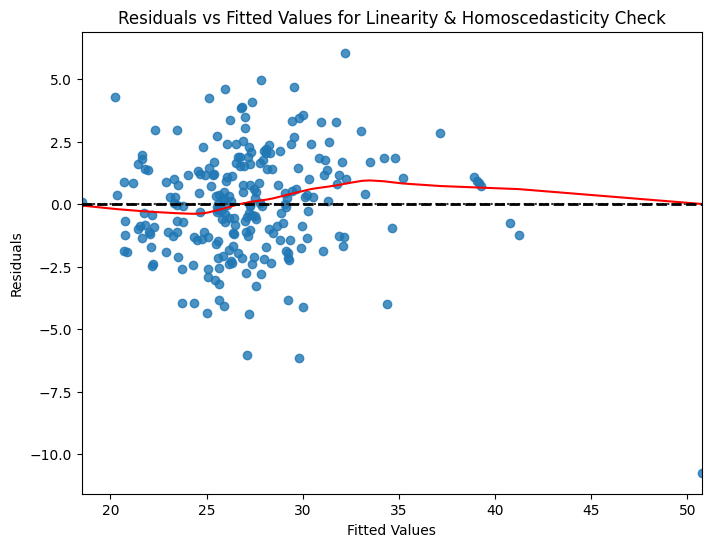

In [ ]:
fitted_vals = results.fittedvalues
residuals = results.resid

plt.figure(figsize=(8, 6))
sns.residplot(x=fitted_vals, y=residuals, lowess=True,
              line_kws={'color': 'red', 'lw': 1.5})  # Add a smooth trendline

plt.axhline(0, color='black', linestyle='--', lw=2)  # Horizontal line at 0
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values for Linearity & Homoscedasticity Check')
plt.show()

Breusch-Pagan statistical test for homoschedascity.

*H0: residuals are homoschedastic*

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(results.resid, X_train_5)

print(f'p-value: {bp_test[1]}')

p-value: 1.6482512198899251e-06


## Gaussianity

Results summary includes the Jacques-Bera test for normality on residuals.

*H0: data are gaussian.*

This test has poor power for n < 100.

Other methods we previosly saw are the QQ-plot (graphical) and the Shapiro-Wilk test (good power for n < 2000)

In [ ]:
print(f'Jacques-Bera test p-value: {results.diagn["jbpv"]:.4f}')

Jacques-Bera test p-value: 0.0000


In [ ]:
sw = stats.shapiro(results.resid).pvalue
print(f'Shapiro-Wilk test p-value: {sw:.4f}')

Shapiro-Wilk test p-value: 0.0009


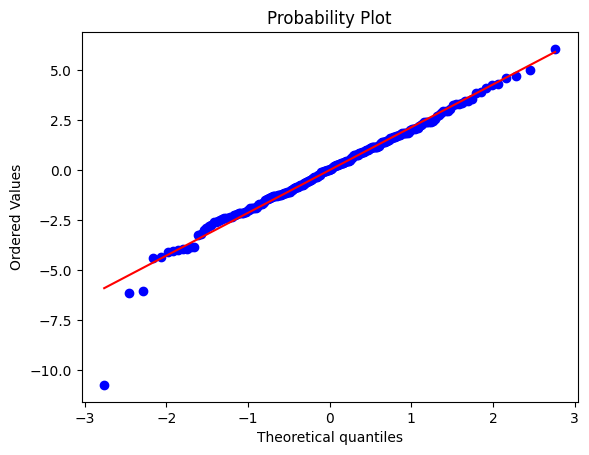

In [ ]:
stats.probplot(results.resid, dist="norm", plot=plt)
plt.show()

Kurtosis of residuals confirms the non gaussianity (gaussian is ~3), they have fatter tails here

In [ ]:
results.diagn['kurtosis']

np.float64(5.1443831971308125)

And also the skeweness, which is not 0

In [ ]:
results.diagn['skew']

np.float64(-0.5007111905863733)

## Transform y

In [ ]:
#y_train_10 = np.sqrt(y_train)
#y_test_10 = np.sqrt(y_test)

y_train_10 = np.log(y_train + 1)
y_test_10 = np.log(y_test + 1)

# y_train_10 = np.cbrt(y_train)
# y_test_10 = np.cbrt(y_test)

model = sm.OLS(y_train_10, X_train_5)
results_new = model.fit()
print(results_new.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     240.0
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           3.01e-71
Time:                        13:34:47   Log-Likelihood:                 268.09
No. Observations:                 239   AIC:                            -528.2
Df Residuals:                     235   BIC:                            -514.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [ ]:
y_pred = results_new.predict(X_test_5)
r2 = r2_score(y_test_10,y_pred)
mse = mean_squared_error(y_test_10,y_pred)
n = len(y_test)
p = X_test_5.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

R2: 0.6238
adj_R2: 0.5964
MSE: 0.0070


In [ ]:
sw = stats.shapiro(results_new.resid).pvalue
print(f'Shapiro-Wilk test p-value: {sw:.4f}')

Shapiro-Wilk test p-value: 0.0011


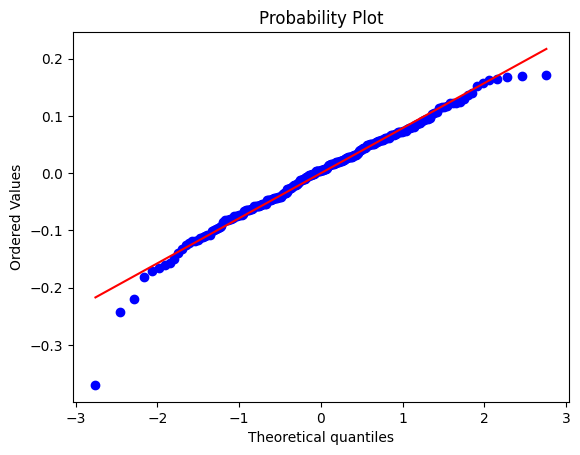

In [ ]:
stats.probplot(results_new.resid, dist="norm", plot=plt)
plt.show()

## Leverages & outliers

**Outliers**: points with a very high residual (bad fit)
Residuals are standardized so to make it easier to spot outliers (those outside +- 2 or +- 3)

**Leverages**: points with unusual value

Hat Matrix $H$ s.t. $\hat{y}=Hy$

$H = X(X^TX)^{-1}X^T$

the leverage of point $i$ is $h_{ii} = x_i^T(X^TX)^{-1}x_i \in (0,1)$



**Cook's distance**: a measure of the point's overall influence of the model

$$
D_i = \frac{r_i^2}{k \cdot \sigma^2} \cdot \frac{h_{ii}}{(1-h_{ii})^2}
$$

combining the size of the (standardized) residuals ($r_i$), with respect to the model parameters ($k$), and the leverage ($h_{ii}$)

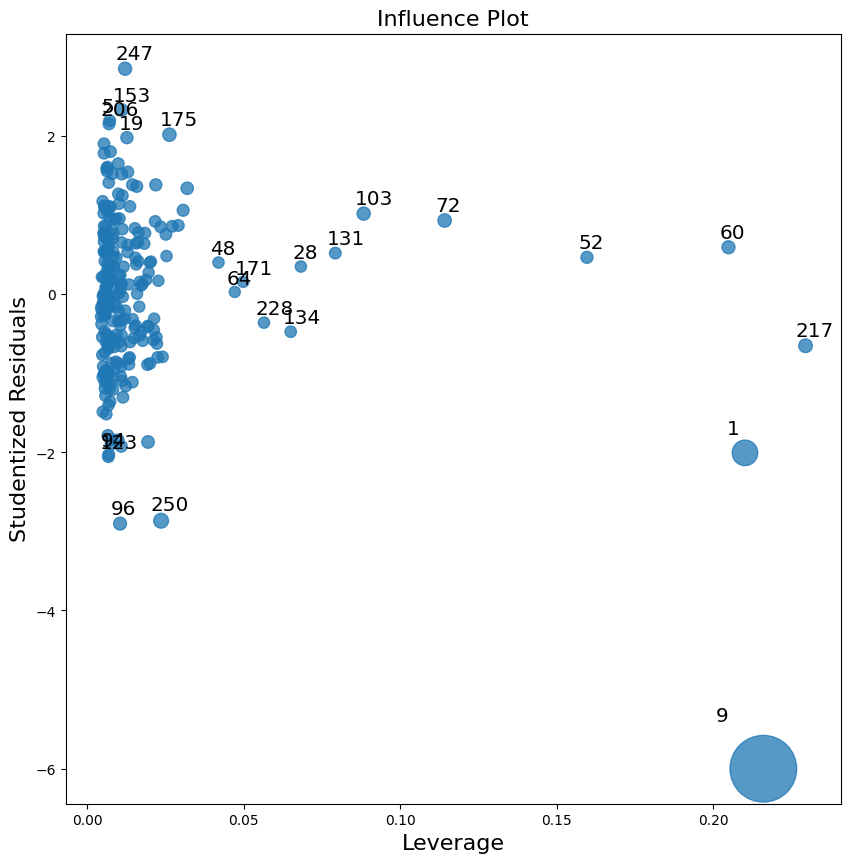

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sm.graphics.influence_plot(results, criterion="cooks", ax=ax);

In [ ]:
influence = results.get_influence()

influence_df = influence.summary_frame()[['cooks_d', 'student_resid', 'hat_diag']]

influence_df = influence_df.rename(columns={'hat_diag': 'leverage'}).sort_values(by='cooks_d', ascending=False)

influence_df

,cooks_d,student_resid,leverage
9,2.16,-6.00,0.22
1,0.26,-2.01,0.21
250,0.05,-2.86,0.02
217,0.03,-0.65,0.23
72,0.03,0.93,0.11
...,...,...,...
37,0.00,0.01,0.01
135,0.00,0.02,0.01
246,0.00,0.01,0.02
214,0.00,-0.01,0.01


<Axes: ylabel='Frequency'>

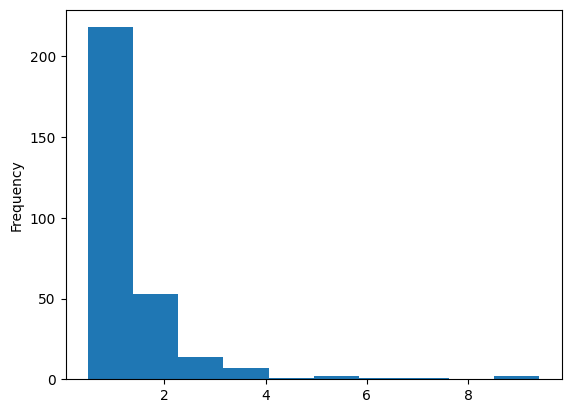

In [ ]:
df['serum_creatinine'].plot(kind='hist')

In [ ]:
X_train_5.loc[9]

,9
const,1.00
ejection_fraction,35.63
serum_creatinine,9.40
creatinine_phosphokinase,123.00


## Removing high leverage outliers

In [ ]:
to_remove = [9]

X_train_11 = X_train_5.drop(to_remove)
y_train_11 = y_train.drop(to_remove)
X_test_11 = X_test_5
y_test_11 = y_test
model = sm.OLS(y_train_11, X_train_11)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     319.9
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           1.76e-82
Time:                        12:42:25   Log-Likelihood:                -503.04
No. Observations:                 238   AIC:                             1014.
Df Residuals:                     234   BIC:                             1028.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [ ]:
sw = stats.shapiro(results.resid).pvalue
print(f'Shapiro-Wilk test p-value: {sw:.4f}')

Shapiro-Wilk test p-value: 0.9159


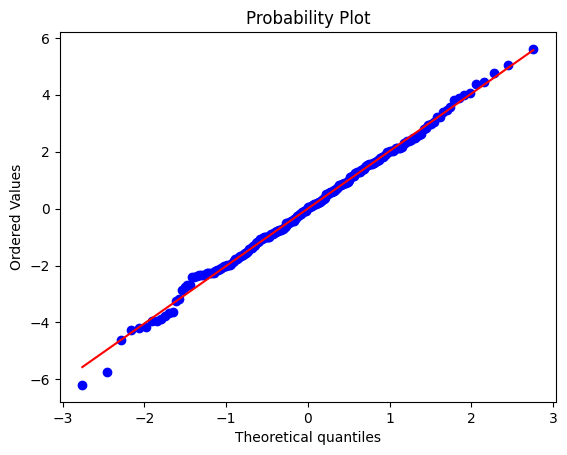

In [ ]:
stats.probplot(results.resid, dist="norm", plot=plt)
plt.show()

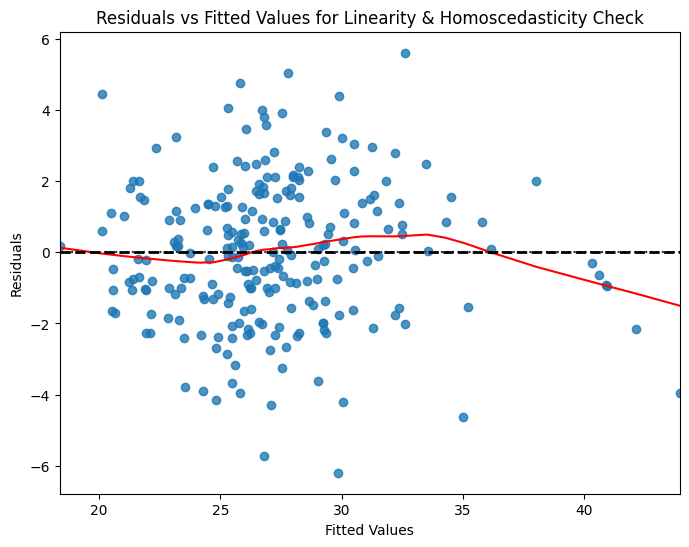

In [ ]:
fitted_vals = results.fittedvalues
residuals = results.resid

plt.figure(figsize=(8, 6))
sns.residplot(x=fitted_vals, y=residuals, lowess=True,
              line_kws={'color': 'red', 'lw': 1.5})  # Add a smooth trendline

plt.axhline(0, color='black', linestyle='--', lw=2)  # Horizontal line at 0
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values for Linearity & Homoscedasticity Check')
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(results.resid, X_train_11)

print(f'p-value: {bp_test[1]}')

p-value: 0.4526627979191319


# Anscombe dataset

Four datasets with nearly identical:

* Mean of
𝑥
and
𝑦

* Variance of
𝑥
and
𝑦

* Correlation between
𝑥
and
𝑦

* Regression line (𝑦 = 3.00 + 0.50𝑥 )

* $𝑅^2$
  and residual standard error

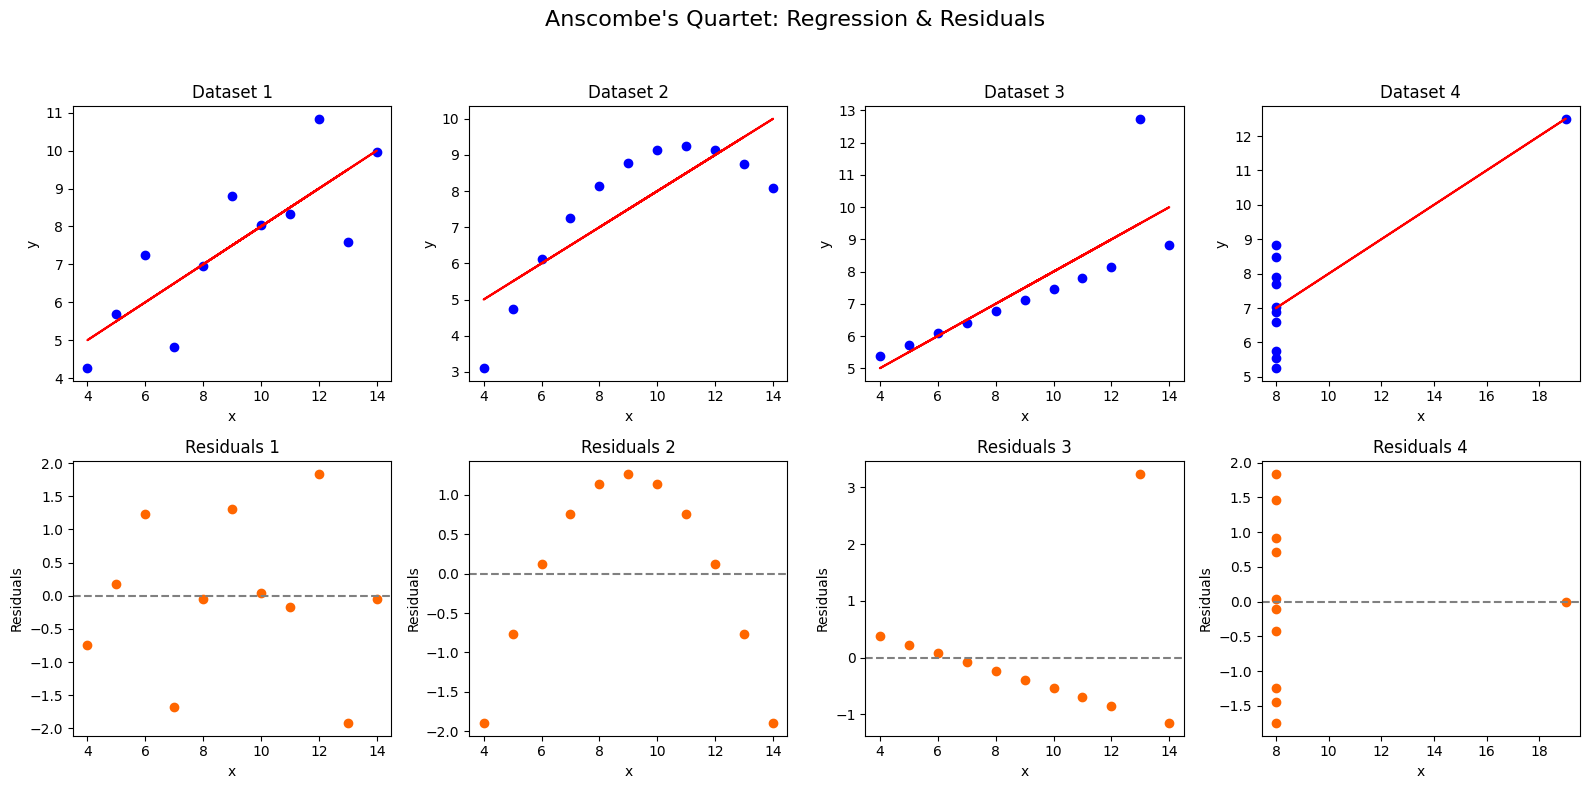


=== Summary for Dataset I ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     17.99
Date:                Wed, 22 Apr 2026   Prob (F-statistic):            0.00217
Time:                        12:49:00   Log-Likelihood:                -16.841
No. Observations:                  11   AIC:                             37.68
Df Residuals:                       9   BIC:                             38.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0001

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load the built-in Anscombe dataset
df = sns.load_dataset("anscombe")

datasets = ['I', 'II', 'III', 'IV']
models = {}

# Plot setup: 2 rows x 4 columns
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Anscombe's Quartet: Regression & Residuals", fontsize=16)

for i, name in enumerate(datasets):
    data = df[df['dataset'] == name]

    x = data['x']
    y = data['y']
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    models[name] = model

    # Scatter plot with regression line (top row)
    ax1 = axes[0, i]
    ax1.scatter(x, y, color='blue')
    ax1.plot(x, model.predict(X), color='red')
    ax1.set_title(f'Dataset {i+1}')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')

    # Residual plot (bottom row)
    ax2 = axes[1, i]
    ax2.scatter(x, model.resid, color='#ff6600')
    ax2.axhline(0, color='gray', linestyle='--')
    ax2.set_title(f'Residuals {i+1}')
    ax2.set_xlabel('x')
    ax2.set_ylabel('Residuals')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Print regression summaries
for name, model in models.items():
    print(f"\n=== Summary for Dataset {name} ===")
    print(model.summary())


For datasets III and IV compute leverages and Cook distances

Dataset III
       x     y  leverage  cooks_distance  residuals  standard_resid
22 10.00  7.46      0.10            0.01      -0.54           -0.46
23  8.00  6.77      0.10            0.00      -0.23           -0.20
24 13.00 12.74      0.24            1.39       3.24            3.00
25  9.00  7.11      0.09            0.01      -0.39           -0.33
26 11.00  7.81      0.13            0.03      -0.69           -0.60
27 14.00  8.84      0.32            0.30      -1.16           -1.14
28  6.00  6.08      0.17            0.00       0.08            0.07
29  4.00  5.39      0.32            0.03       0.39            0.38
30 12.00  8.15      0.17            0.06      -0.85           -0.76
31  7.00  6.42      0.13            0.00      -0.08           -0.07
32  5.00  5.73      0.24            0.01       0.23            0.21


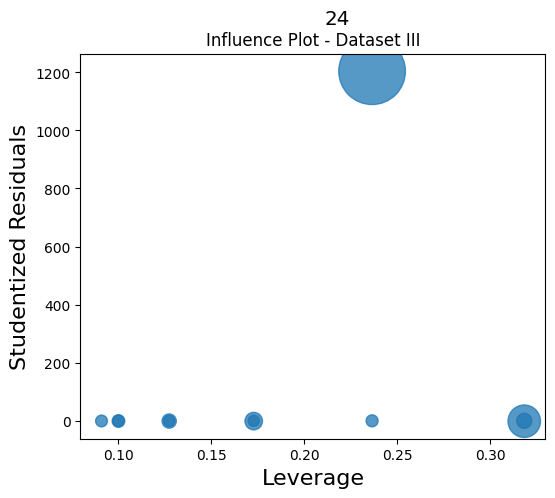

Dataset IV
       x     y  leverage  cooks_distance  residuals  standard_resid
33  8.00  6.58      0.10            0.01      -0.42           -0.36
34  8.00  5.76      0.10            0.06      -1.24           -1.06
35  8.00  7.71      0.10            0.02       0.71            0.60
36  8.00  8.84      0.10            0.14       1.84            1.57
37  8.00  8.47      0.10            0.09       1.47            1.25
38  8.00  7.04      0.10            0.00       0.04            0.03
39  8.00  5.25      0.10            0.12      -1.75           -1.49
40 19.00 12.50      1.00             NaN       0.00             NaN
41  8.00  5.56      0.10            0.08      -1.44           -1.23
42  8.00  7.91      0.10            0.03       0.91            0.78
43  8.00  6.89      0.10            0.00      -0.11           -0.10


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


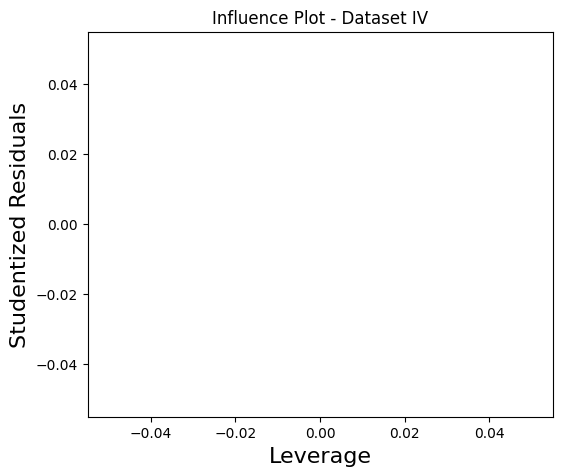

In [ ]:
for dataset_label in ['III', 'IV']:
    print(f"Dataset {dataset_label}")

    # Filter data
    data = df[df['dataset'] == dataset_label]
    x = data['x']
    y = data['y']
    X = sm.add_constant(x)

    # Fit OLS model
    model = sm.OLS(y, X).fit()

    # Get influence measures
    influence = model.get_influence()
    leverage = influence.hat_matrix_diag
    cooks_d = influence.cooks_distance[0]  # [0] is Cook's D values, [1] are p-values

    # Create result DataFrame
    diagnostics_df = pd.DataFrame({
        'x': x,
        'y': y,
        'leverage': leverage,
        'cooks_distance': cooks_d,
        'residuals': model.resid,
        'standard_resid': influence.resid_studentized_internal
    }, index=data.index)

    print(diagnostics_df.round(3))

    # Influence plot
    fig, ax = plt.subplots(figsize=(6, 5))
    sm.graphics.influence_plot(model, ax=ax, criterion="cooks")
    plt.title(f'Influence Plot - Dataset {dataset_label}')
    plt.show()

For dataset IV it is not even possible to compute the Influence plot, because there is a point (point n. 40, with x=19) for which the leverage = 1 and consequently the formula to compute Cook's distance as a denominator of zero, implying an infinite Cook's distance! This happens when a single point completely control the shape of model

# Bias-variance tradeoff

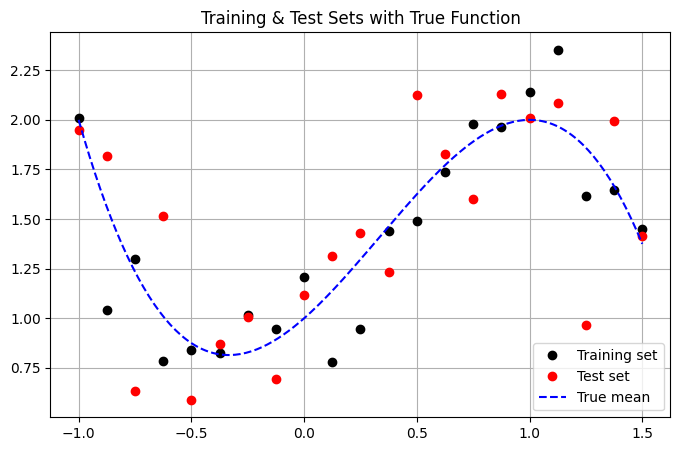

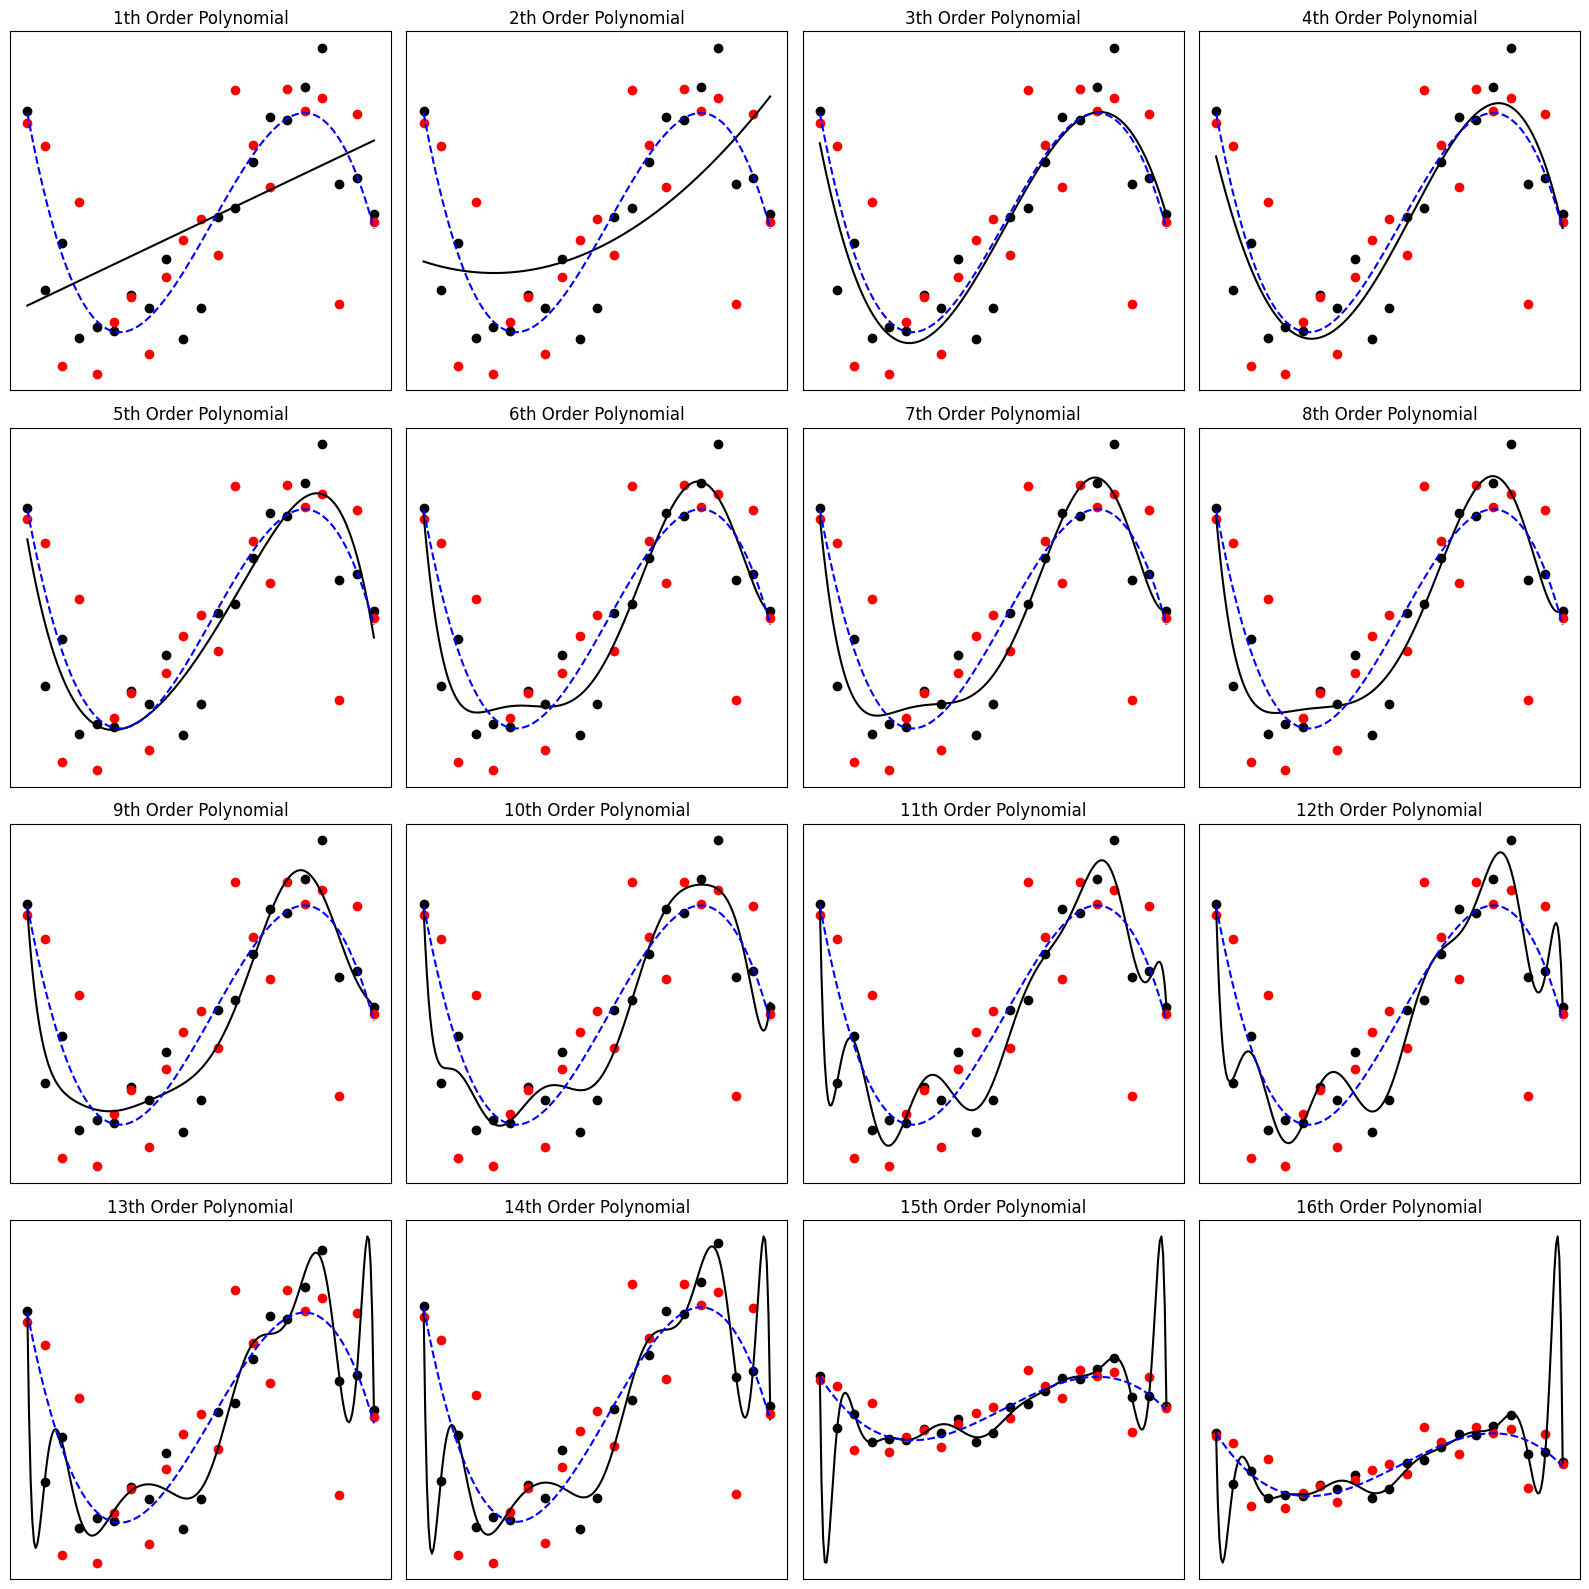

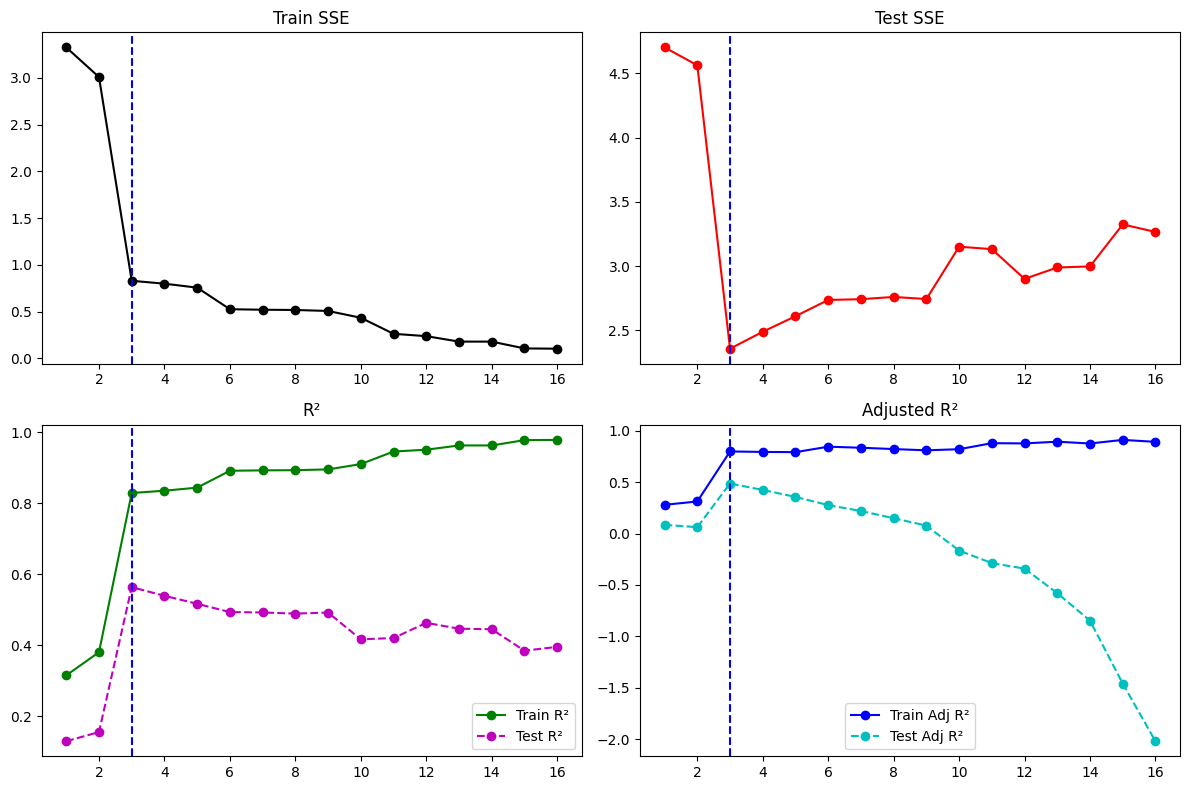

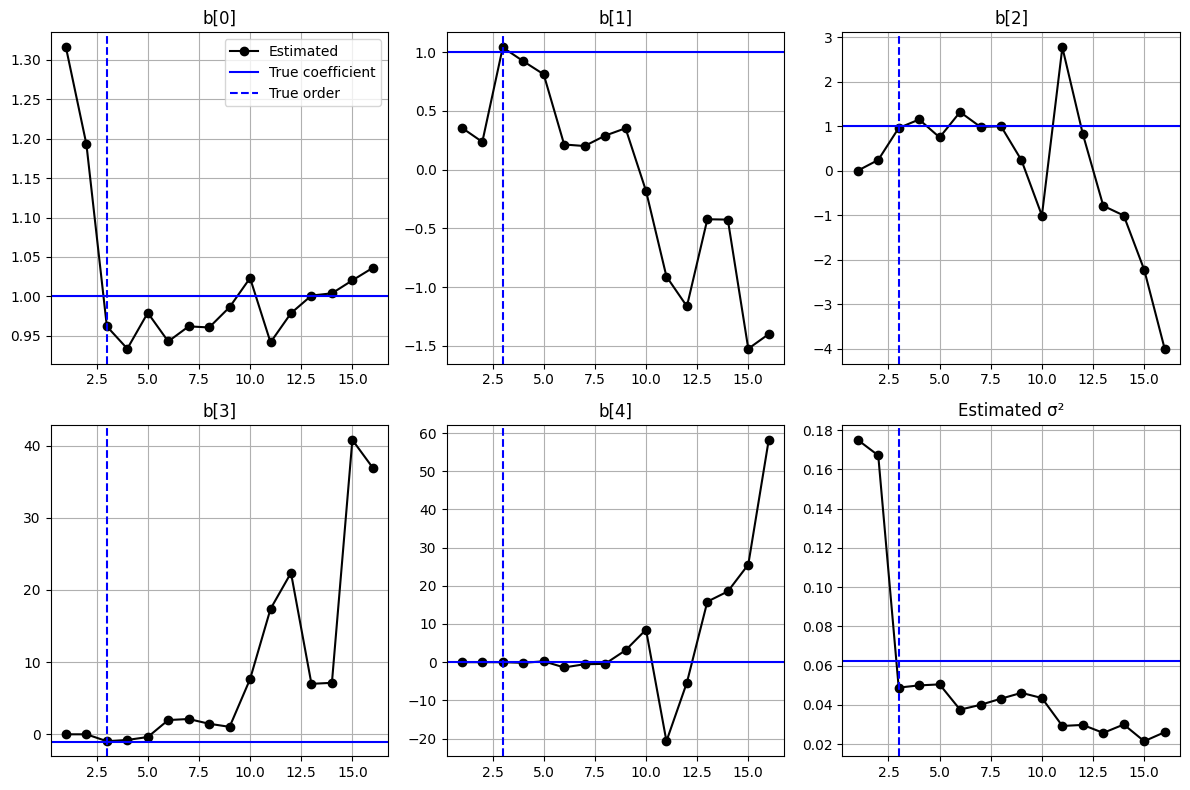

In [ ]:
# True model
def f(x):
    return 1 + x + x**2 - x**3

sigma = 0.25

# Input locations
x_train = np.linspace(-1, 1.5, 21)
x_test = np.linspace(-1, 1.5, 21)

# Responses
y_train = f(x_train) + np.random.normal(0, sigma, size=x_train.shape)
y_test = f(x_test) + np.random.normal(0, sigma, size=x_test.shape)

# Build design matrices up to degree 20
max_degree = 20
X_train = np.column_stack([x_train**p for p in range(max_degree + 1)])
X_test = np.column_stack([x_test**p for p in range(max_degree + 1)])

X_train_df = pd.DataFrame(X_train, columns=[f'x{p}' for p in range(max_degree + 1)])
X_test_df = pd.DataFrame(X_test, columns=[f'x{p}' for p in range(max_degree + 1)])

# Grid for plotting
x_plot = np.linspace(-1, 1.5, 210)
X_plot = np.column_stack([x_plot**p for p in range(max_degree + 1)])
X_plot_df = pd.DataFrame(X_plot, columns=[f'x{p}' for p in range(max_degree + 1)])

# Plot data
plt.figure(figsize=(8, 5))
plt.plot(x_train, y_train, 'ko', label='Training set')
plt.plot(x_test, y_test, 'ro', label='Test set')
plt.plot(x_plot, f(x_plot), 'b--', label='True mean')
plt.legend(loc='lower right')
plt.title("Training & Test Sets with True Function")
plt.grid(True)
plt.show()

# Containers
SSres_train, SSres_test = [], []
R2_train, R2_test = [], []
R2_adj_train, R2_adj_test = [], []
s2, coeffs_all = [], []

n_train = len(y_train)
n_test = len(y_test)

# Fit models
plt.figure(figsize=(16, 16))

for degree in range(1, 17):
    X_train_p = X_train_df.iloc[:, :degree + 1]
    X_test_p = X_test_df.iloc[:, :degree + 1]
    X_plot_p = X_plot_df.iloc[:, :degree + 1]

    model = sm.OLS(y_train, X_train_p).fit()

    # Predictions
    yhat_train = model.predict(X_train_p)
    yhat_test = model.predict(X_test_p)
    yhat_plot = model.predict(X_plot_p)

    # Plot
    plt.subplot(4, 4, degree)
    plt.plot(x_train, y_train, 'ko')
    plt.plot(x_test, y_test, 'ro')
    plt.plot(x_plot, yhat_plot, 'k-')
    plt.plot(x_plot, f(x_plot), 'b--')
    plt.title(f'{degree}th Order Polynomial')
    plt.xticks([]); plt.yticks([])

    # Residuals
    res_train = y_train - yhat_train
    res_test = y_test - yhat_test

    SSres_train.append(np.sum(res_train**2))
    SSres_test.append(np.sum(res_test**2))

    # Variance estimate
    s2.append(np.sum(res_train**2) / (n_train - (degree + 1)))

    # R^2
    r2_train = r2_score(y_train, yhat_train)
    r2_test = r2_score(y_test, yhat_test)

    R2_train.append(r2_train)
    R2_test.append(r2_test)

    # Adjusted R^2
    R2_adj_train.append(1 - (1 - r2_train) * (n_train - 1) / (n_train - degree - 1))

    # Heuristic adjusted R^2 on test
    R2_adj_test.append(1 - (1 - r2_test) * (n_test - 1) / (n_test - degree - 1))

    # Store coefficients
    coeffs = np.zeros(17)
    coeffs[:degree + 1] = model.params
    coeffs_all.append(coeffs)

plt.tight_layout()
plt.show()

# Coefficients matrix
b = np.array(coeffs_all).T

# Performance plots
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(range(1, 17), SSres_train, 'ko-')
plt.axvline(3, color='blue', linestyle='--')
plt.title("Train SSE")

plt.subplot(2, 2, 2)
plt.plot(range(1, 17), SSres_test, 'ro-')
plt.axvline(3, color='blue', linestyle='--')
plt.title("Test SSE")

plt.subplot(2, 2, 3)
plt.plot(range(1, 17), R2_train, 'go-', label='Train R²')
plt.plot(range(1, 17), R2_test, 'mo--', label='Test R²')
plt.axvline(3, color='blue', linestyle='--')
plt.title("R²")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(range(1, 17), R2_adj_train, 'bo-', label='Train Adj R²')
plt.plot(range(1, 17), R2_adj_test, 'co--', label='Test Adj R²')
plt.axvline(3, color='blue', linestyle='--')
plt.title("Adjusted R²")
plt.legend()

plt.tight_layout()
plt.show()

# Coefficients comparison
b_true = np.array([1, 1, 1, -1] + [0]*13)

plt.figure(figsize=(12, 8))
for i in range(5):
    plt.subplot(2, 3, i + 1)
    plt.plot(range(1, 17), b[i], 'ko-')
    plt.axhline(b_true[i], color='blue')
    plt.axvline(3, color='blue', linestyle='--')
    plt.title(f'b[{i}]')
    plt.grid(True)
    if i == 0:
        plt.legend(['Estimated', 'True coefficient', 'True order'])

plt.subplot(2, 3, 6)
plt.plot(range(1, 17), s2, 'ko-')
plt.axhline(sigma**2, color='blue')
plt.axvline(3, color='blue', linestyle='--')
plt.title("Estimated σ²")
plt.grid(True)

plt.tight_layout()
plt.show()

# Homework

What happens if instead you model the ejection fraction as the dependent variable?

Try to build the best linear regression model to predict ejection fraction

# Feedback

Please leave a feedback on this lab through [this form](https://forms.office.com/e/Zg4LdMgDBU) (estimated 2 minutes)